# LSTM Word2Vec Baseline

Frozen Word2Vec embeddings with a unidirectional LSTM classifier.

In [ ]:
from pathlib import Path
import os
import sys
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "lstm_w2vec_sota.yaml"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figure" / "02_training"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def display_saved_figures(paths):
    if isinstance(paths, dict):
        paths = paths.values()
    elif isinstance(paths, (str, Path)):
        paths = [paths]

    for path in paths:
        display(Image(filename=str(path)))

CONFIG_PATH

PosixPath('/home/coronny/sentiment_analysis/configs/experiment.yaml')

In [2]:
from src.trainer import train_baseline

history = train_baseline(str(CONFIG_PATH))
history

/home/coronny/sentiment_analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/coronny/sentiment_analysis/.venv/lib/python3.13/site-packages/pyvi/ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


---Đang tải datasets UIT ---


Saving the dataset (1/1 shards): 100%|██████████| 3166/3166 [00:00<00:00, 451964.41 examples/s]


Đã tải xong! Train: 11426 câu.
--Xây dựng bộ vocab ---
Bộ từ vựng hiện tại có 2059 từ.
Epoch 1/50 | Train Loss: 0.7828 | Val Loss: 0.5978 | Train Acc: 0.7773 | Val Acc: 0.8642
Epoch 2/50 | Train Loss: 0.5415 | Val Loss: 0.5289 | Train Acc: 0.8726 | Val Acc: 0.8692
Epoch 3/50 | Train Loss: 0.4898 | Val Loss: 0.4949 | Train Acc: 0.8762 | Val Acc: 0.8806
Epoch 4/50 | Train Loss: 0.4653 | Val Loss: 0.4855 | Train Acc: 0.8778 | Val Acc: 0.8812
Epoch 5/50 | Train Loss: 0.4484 | Val Loss: 0.4595 | Train Acc: 0.8796 | Val Acc: 0.8863
Epoch 6/50 | Train Loss: 0.4348 | Val Loss: 0.4469 | Train Acc: 0.8801 | Val Acc: 0.8857
Epoch 7/50 | Train Loss: 0.4213 | Val Loss: 0.4367 | Train Acc: 0.8848 | Val Acc: 0.8863
Epoch 8/50 | Train Loss: 0.4145 | Val Loss: 0.4299 | Train Acc: 0.8878 | Val Acc: 0.8882
Epoch 9/50 | Train Loss: 0.3983 | Val Loss: 0.4364 | Train Acc: 0.8879 | Val Acc: 0.8964
Early stopping monitor: 1/6 epochs without validation-loss improvement. Best Val Loss: 0.4299
Epoch 10/50 | Trai

{'train_loss': [0.7828154226338397,
  0.541493742034755,
  0.4898340366988875,
  0.4653119987199426,
  0.44839321347421773,
  0.4347588838853317,
  0.4213266550412391,
  0.41450196161200215,
  0.39831107325185944,
  0.3884090400566269,
  0.38076558911017866,
  0.37077694157315366,
  0.361798890559367,
  0.3523711872718937,
  0.35121304591774277,
  0.3408168403538433,
  0.33209879455994296,
  0.3276960770677588,
  0.32065540052789093,
  0.31442229989812026,
  0.30841658970532293,
  0.30300993382197144,
  0.2989127950524318,
  0.29329311822517645],
 'val_loss': [0.5977644896507264,
  0.528930869102478,
  0.4949174526333809,
  0.48545729398727416,
  0.4595418614149094,
  0.44692262142896655,
  0.4367022541165352,
  0.42992412984371187,
  0.43641314148902893,
  0.42144433066248893,
  0.412235664576292,
  0.4118224549293518,
  0.40784189477562904,
  0.4038201116025448,
  0.4089418876171112,
  0.40136452376842496,
  0.39768481612205503,
  0.39441250324249266,
  0.399153653383255,
  0.3987209

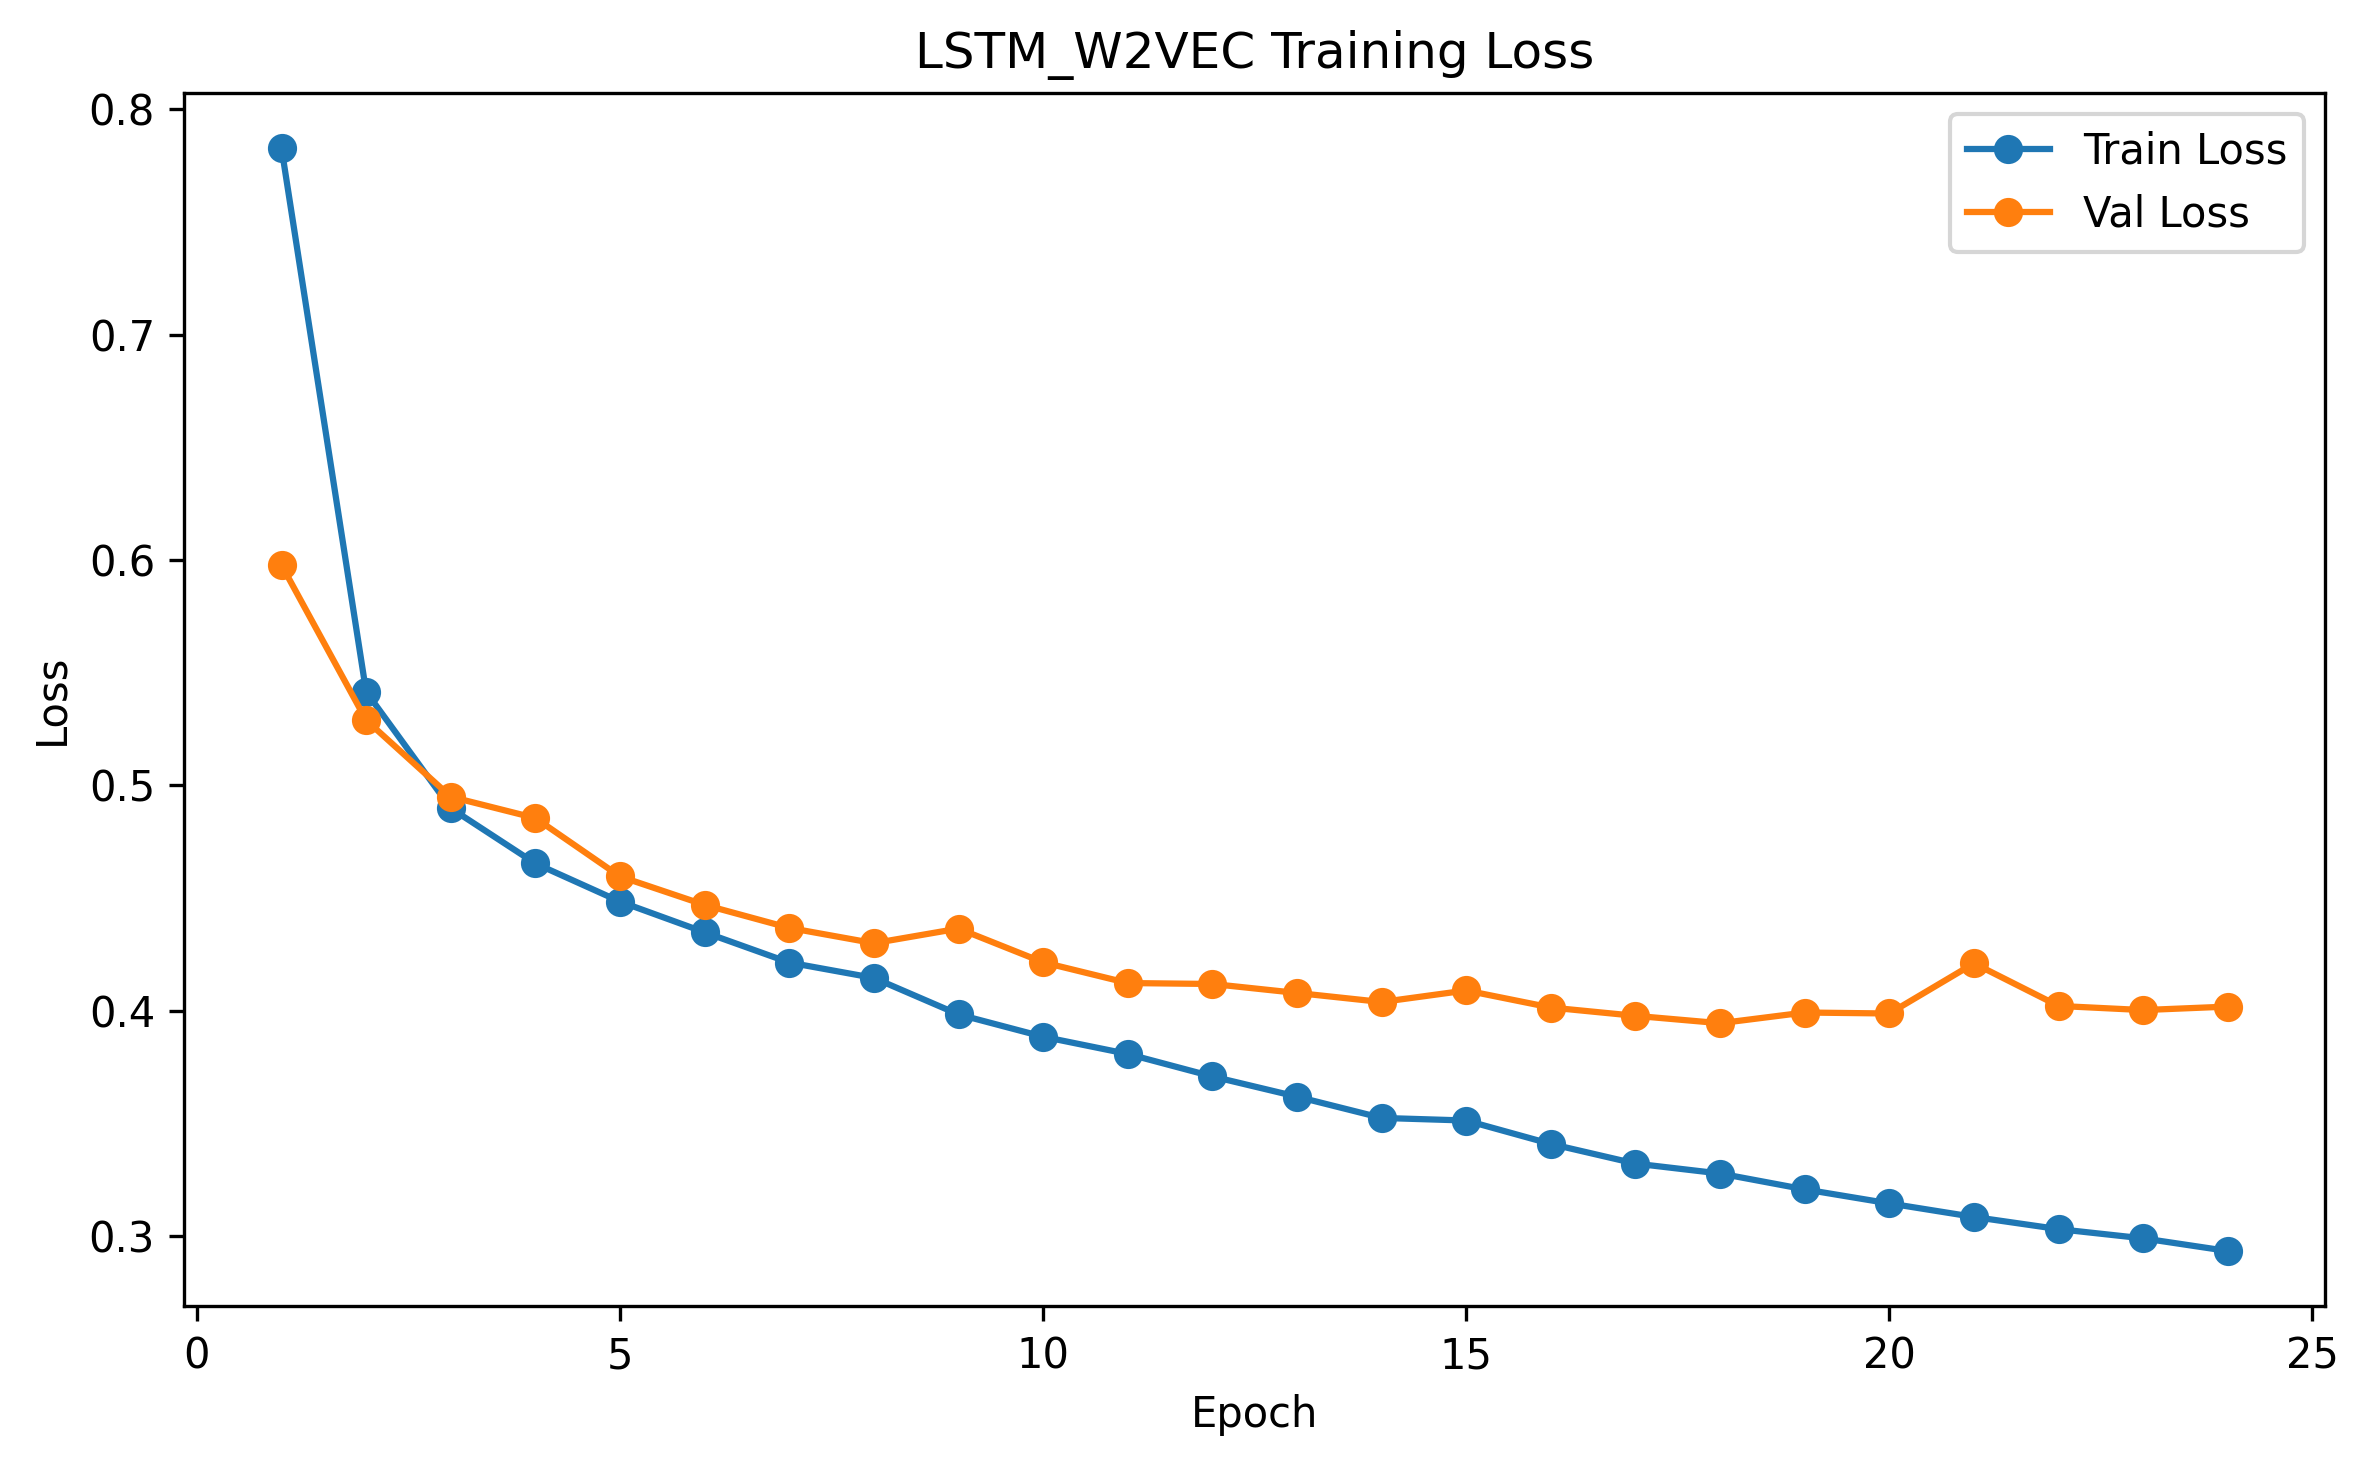

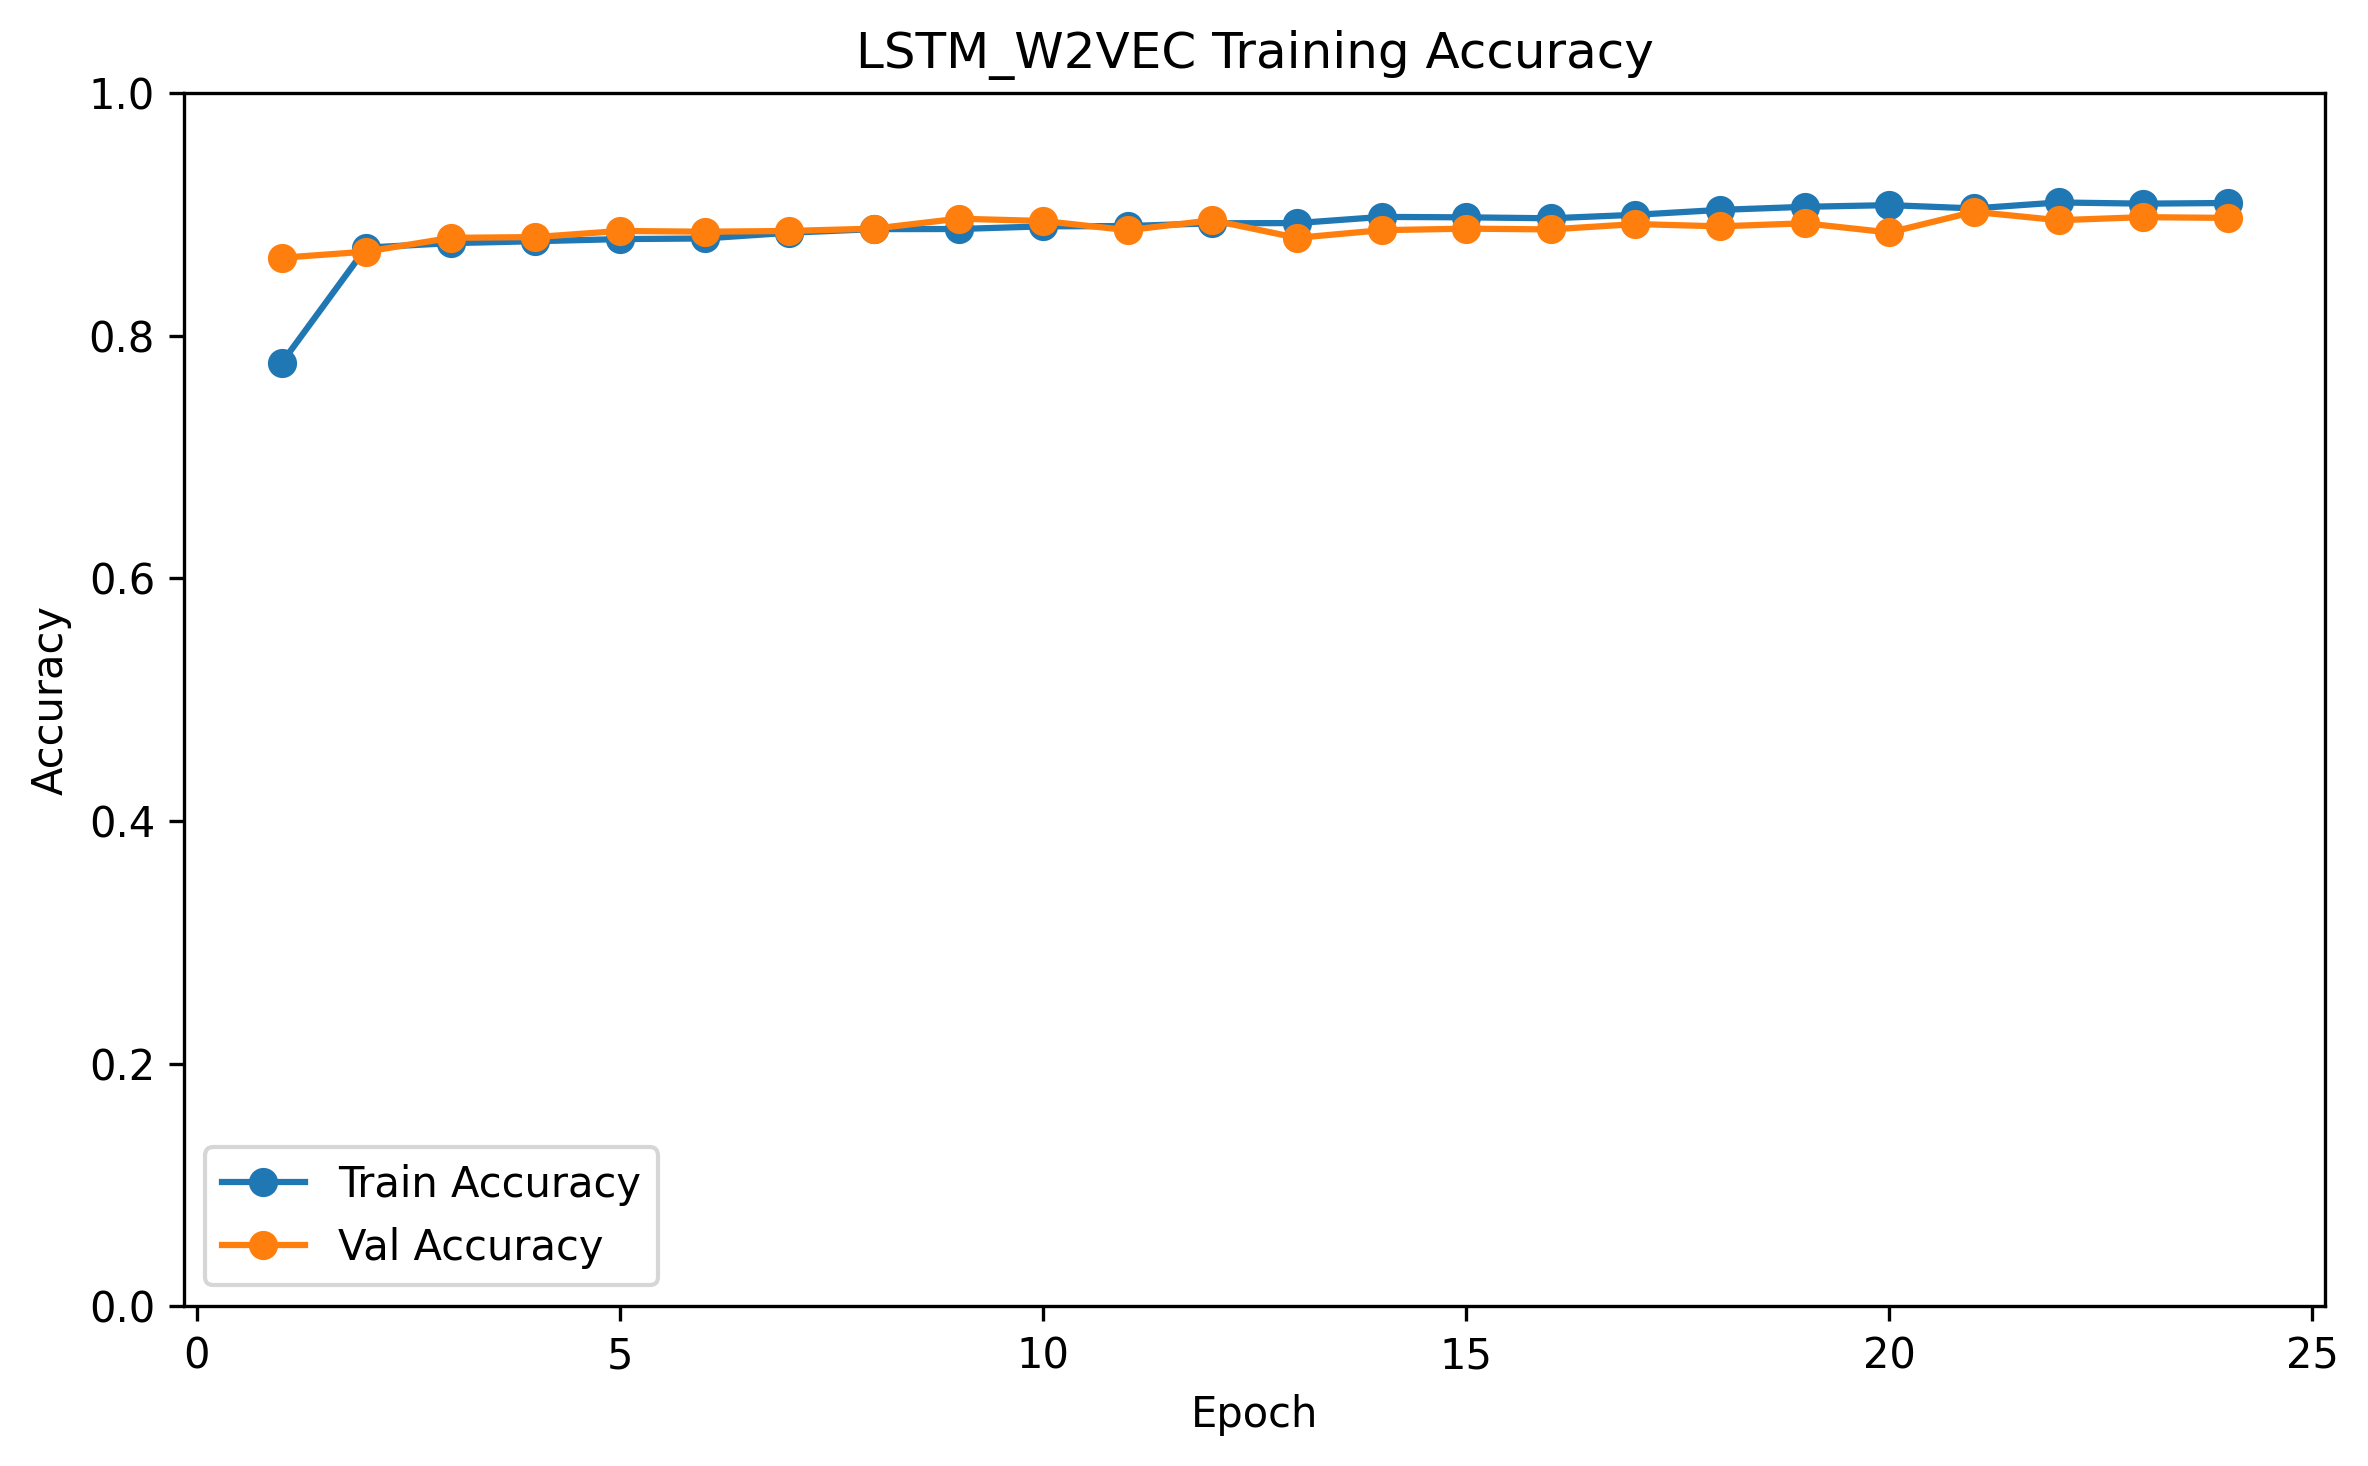

{'loss': PosixPath('/home/coronny/sentiment_analysis/reports/figure/02_training/lstm_w2vec_feature100_dropout0_3_loss.png'),
 'accuracy': PosixPath('/home/coronny/sentiment_analysis/reports/figure/02_training/lstm_w2vec_feature100_dropout0_3_accuracy.png')}

In [3]:
from src.utils import load_config, plot_training_curves

config = load_config(CONFIG_PATH)
curve_paths = plot_training_curves(
    history,
    model_name="lstm_w2vec",
    max_features=config["features"]["word2vec"]["vector_size"],
    dropout=config["models"]["lstm"].get("dropout", 0.0),
    output_dir=FIGURE_DIR,
)
display_saved_figures(curve_paths)
curve_paths

---Đang tải datasets UIT ---


Saving the dataset (1/1 shards): 100%|██████████| 3166/3166 [00:00<00:00, 508585.46 examples/s]


Đã tải xong! Train: 11426 câu.
--Xây dựng bộ vocab ---
Bộ từ vựng hiện tại có 2059 từ.


/home/coronny/sentiment_analysis/src/utils.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metric_names, y=metric_values, palette="viridis")


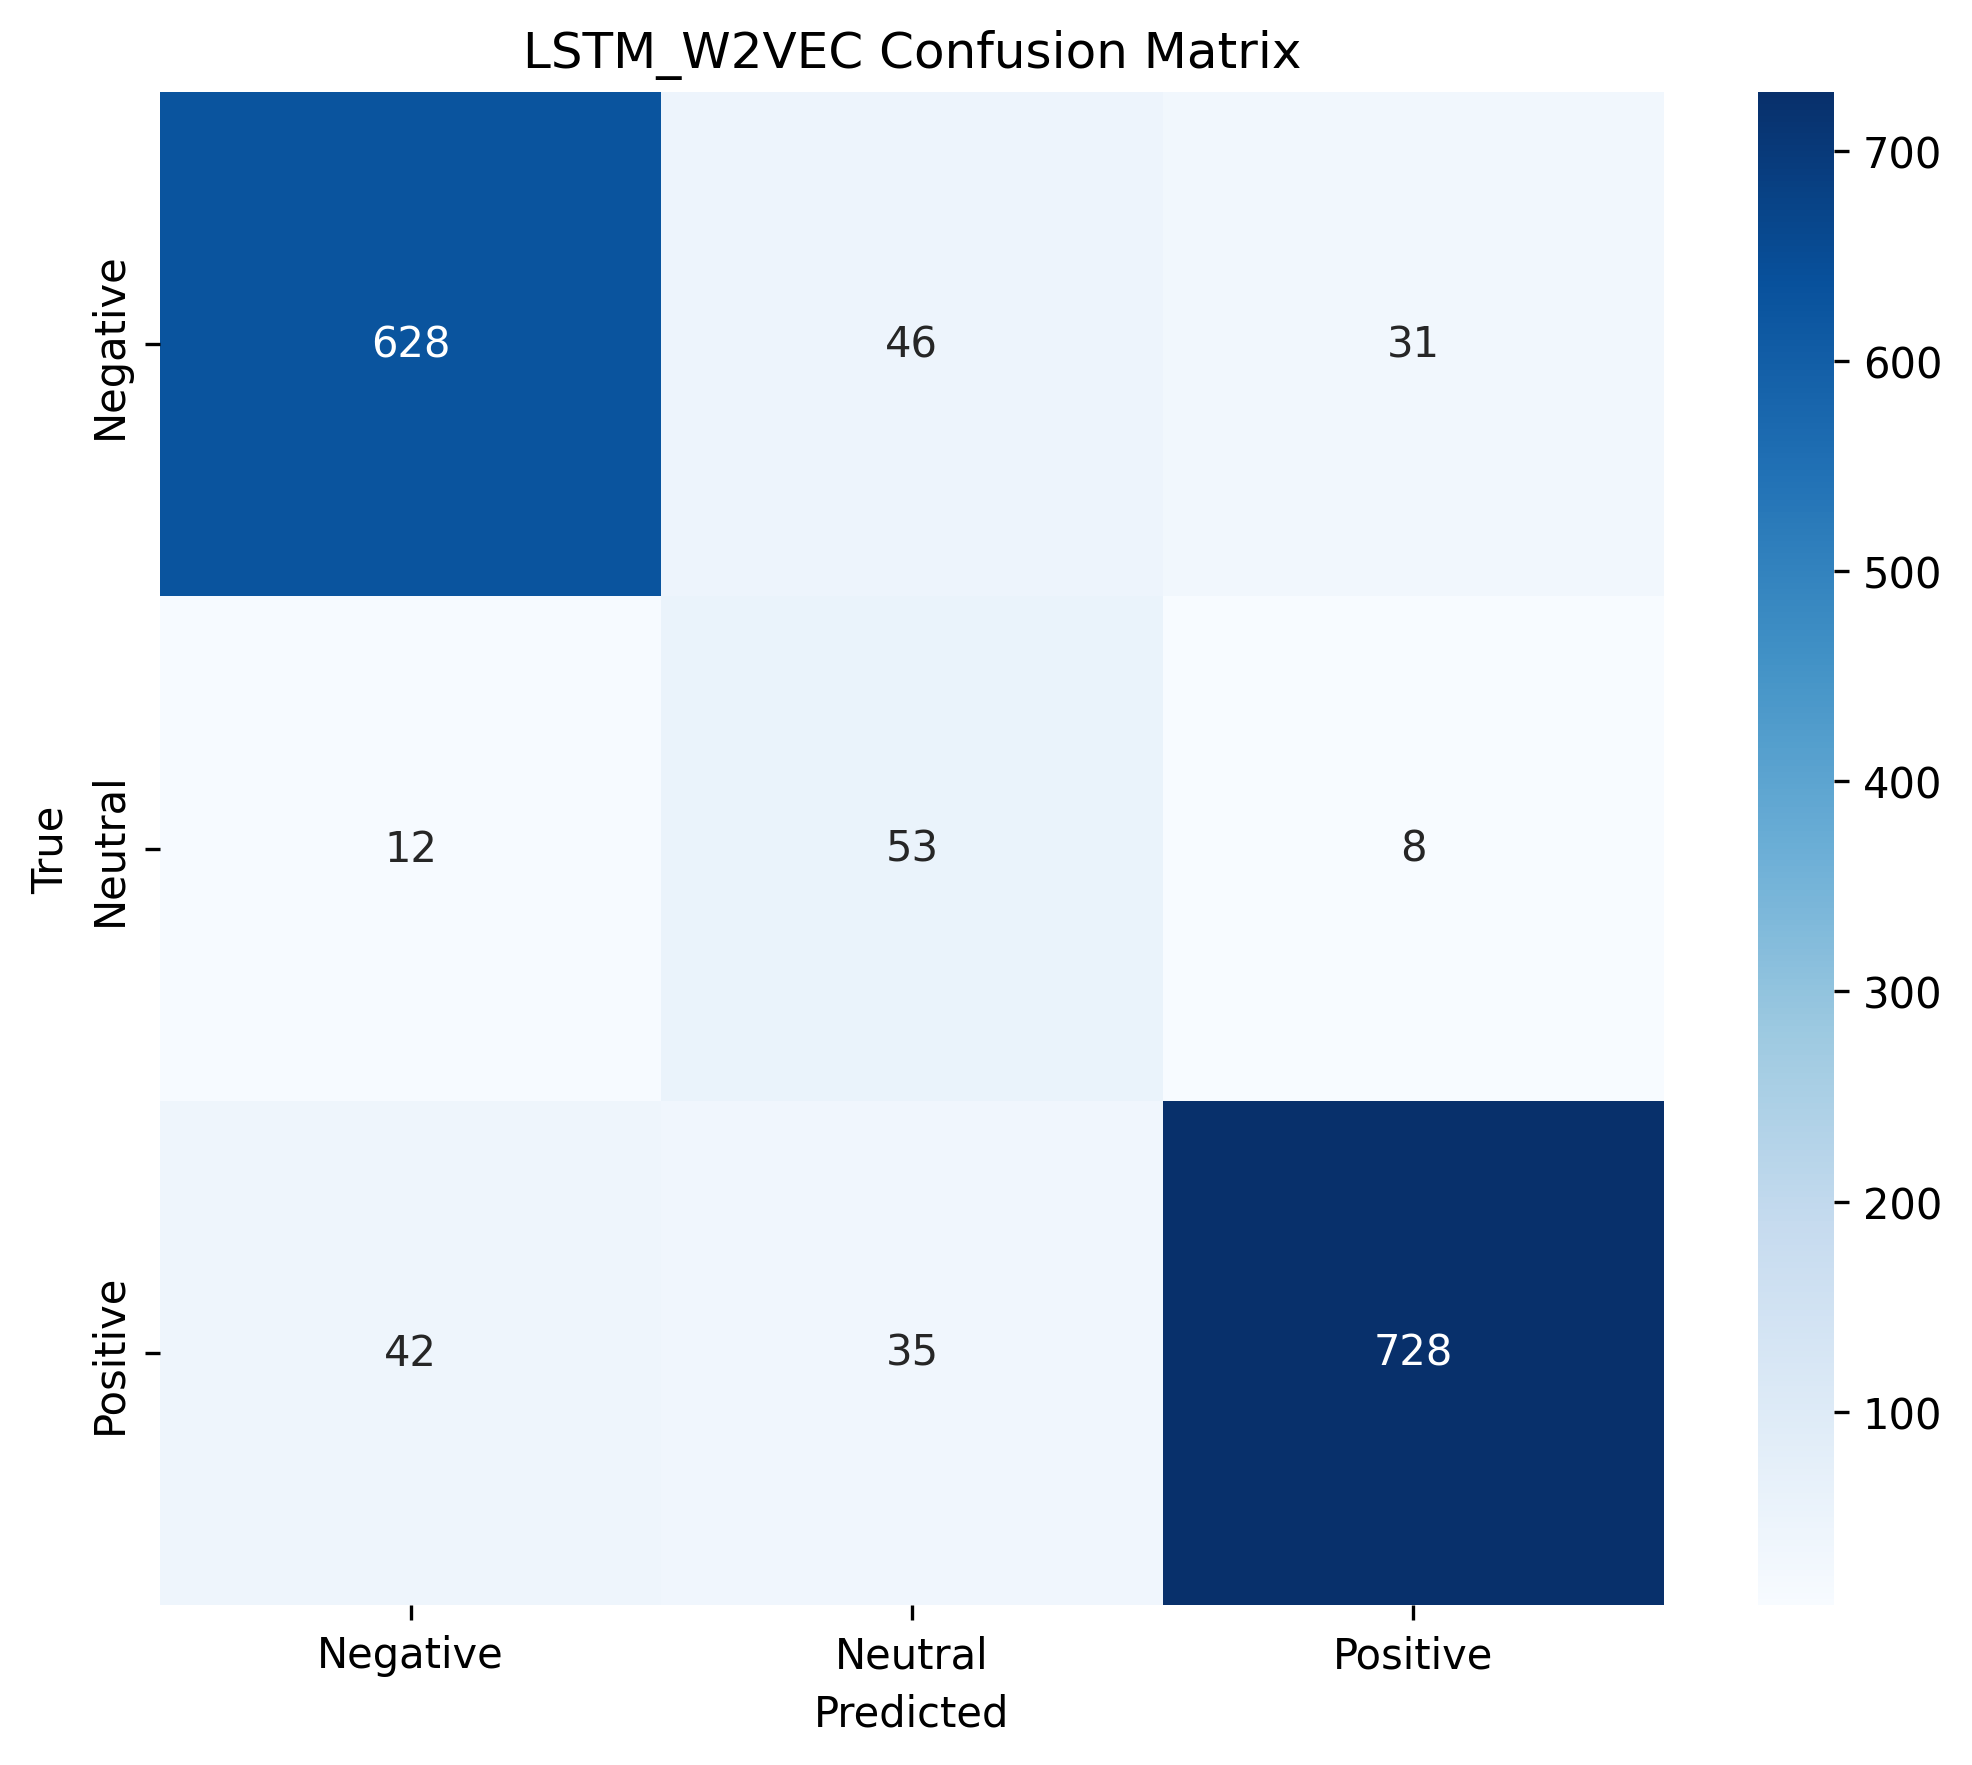

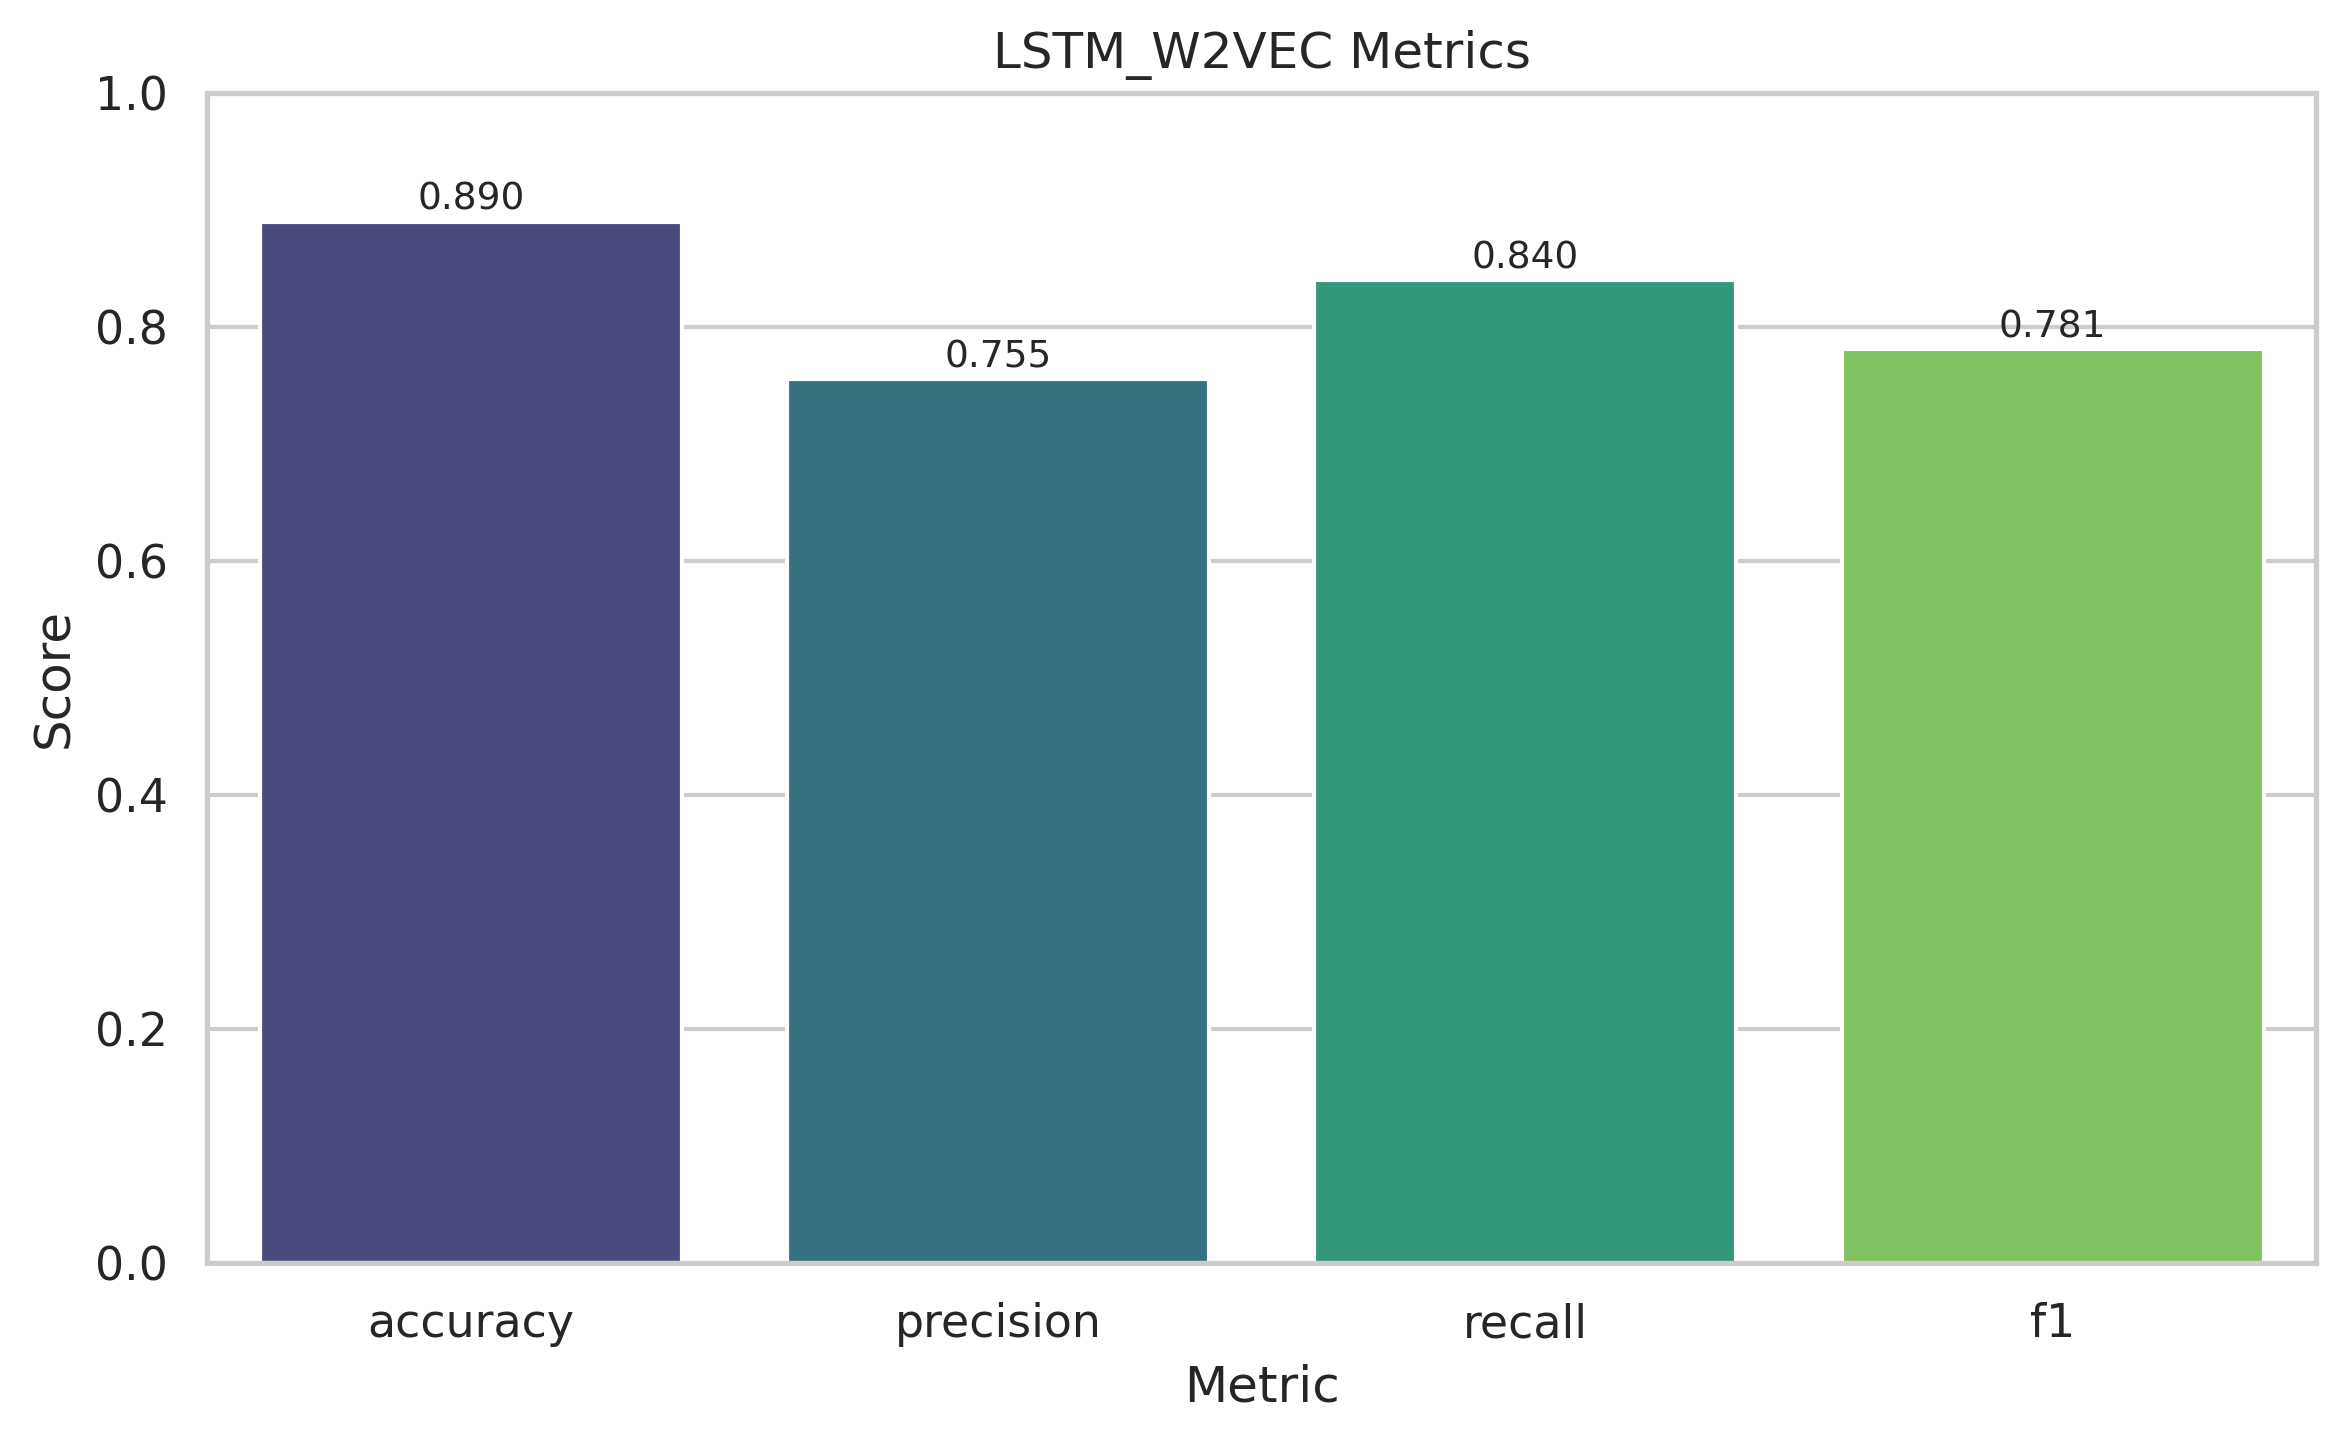

({'accuracy': 0.8900821225521163,
  'precision': 0.7551653482673615,
  'recall': 0.8403851217304007,
  'f1': 0.7812791653978762},
 PosixPath('/home/coronny/sentiment_analysis/reports/figure/02_training/lstm_w2vec_confusion_matrix.png'),
 PosixPath('/home/coronny/sentiment_analysis/reports/figure/02_training/lstm_w2vec_metrics.png'))

In [4]:
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from src.trainer import build_model, prepare_lstm_dataloaders, resolve_device
from src.utils import plot_confusion_matrix, plot_metrics_bar

config = load_config(CONFIG_PATH)
device = resolve_device(config["training"]["device"])
_, val_loader, artifacts = prepare_lstm_dataloaders(config)
model = build_model(config, embedding_matrix=artifacts["embedding_matrix"]).to(device)

checkpoint = torch.load(PROJECT_ROOT / "checkpoints" / "lstm_w2vec_best_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

y_true = []
y_pred = []
def unpack_lstm_batch(batch):
    if len(batch) == 3:
        return batch

    x_batch, y_batch = batch
    lengths = (x_batch != 0).sum(dim=1).clamp(min=1)
    return x_batch, lengths, y_batch

with torch.no_grad():
    for batch in val_loader:
        x_batch, lengths, y_batch = unpack_lstm_batch(batch)
        logits = model(x_batch.to(device), lengths.to(device))
        preds = torch.argmax(logits, dim=1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(y_batch.cpu().numpy())

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision,
    "recall": recall,
    "f1": f1,
}

cm_path = plot_confusion_matrix(y_true, y_pred, ["Negative", "Neutral", "Positive"], "lstm_w2vec", FIGURE_DIR)
metrics_path = plot_metrics_bar(metrics, "lstm_w2vec", "metrics", FIGURE_DIR)
display_saved_figures([cm_path, metrics_path])
metrics, cm_path, metrics_path